import pandas as pd
import numpy as np
from tensorflow.keras.models import sequential


In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

I0000 00:00:1777977801.636524   16345 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777977801.674538   16345 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777977802.683178   16345 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [22]:
data=pd.read_csv("boston.csv")

In [5]:
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
X=data.drop("MEDV",axis=1)
y=data["MEDV"]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [8]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [9]:
model=Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1)
])

E0000 00:00:1777977815.959868   16345 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(optimizer='adam',loss='mse',metrics=['accuracy'])

In [11]:
history=model.fit(X_train,y_train,epochs=50,batch_size=8,verbose=1,validation_data=(X_test,y_test))

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 562.5125 - val_accuracy: 0.0000e+00 - val_loss: 482.4582
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 363.3958 - val_accuracy: 0.0000e+00 - val_loss: 183.7543
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 107.4145 - val_accuracy: 0.0000e+00 - val_loss: 46.7178
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 44.6703 - val_accuracy: 0.0000e+00 - val_loss: 28.2213
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 30.4062 - val_accuracy: 0.0000e+00 - val_loss: 23.0673
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 25.8801 - val_accuracy: 0.0000e+00 - val_loss: 20.5373
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 23.2366 - val_accuracy: 0.0000e+00 - val_loss: 18.8844
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

In [12]:
loss=model.evaluate(X_test,y_test)
print('loss : ',loss)
pred=model.predict(X_test)
#print('predict : ',pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 10.8551 
loss :  [10.855096817016602, 0.0]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [17]:
pred = pred.flatten()
# Compare actual vs predicted
for i in range(10):   # show first 10 values
    print("Actual:", y_test.iloc[i], " Predicted:", pred[i])

Actual: 17.8  Predicted: 16.1302
Actual: 21.7  Predicted: 17.815119
Actual: 11.3  Predicted: 10.983956
Actual: 24.3  Predicted: 19.35892
Actual: 16.3  Predicted: 11.03551
Actual: 24.7  Predicted: 22.470547
Actual: 23.7  Predicted: 24.617264
Actual: 7.2  Predicted: 11.406391
Actual: 21.4  Predicted: 21.055462
Actual: 30.8  Predicted: 28.036045


<function matplotlib.pyplot.show(close=None, block=None)>

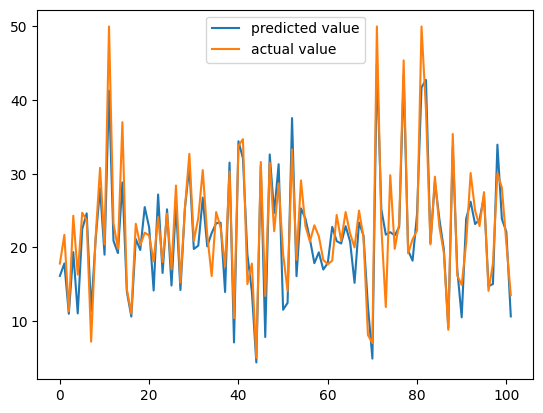

In [18]:
plt.plot(pred,label='predicted value')
plt.plot(y_test.values,label='actual value')
plt.legend()
plt.show